# Assignment 2
**Author:** Lan Stare
**Date:** 21. 9. 2025


### (a)

(array([[ 2., -1.,  0., ...,  0.,  0.,  0.],
       [-1.,  2., -1., ...,  0.,  0.,  0.],
       [ 0., -1.,  2., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  2., -1.,  0.],
       [ 0.,  0.,  0., ..., -1.,  2., -1.],
       [ 0.,  0.,  0., ...,  0., -1.,  2.]]), 6743.676611184838)


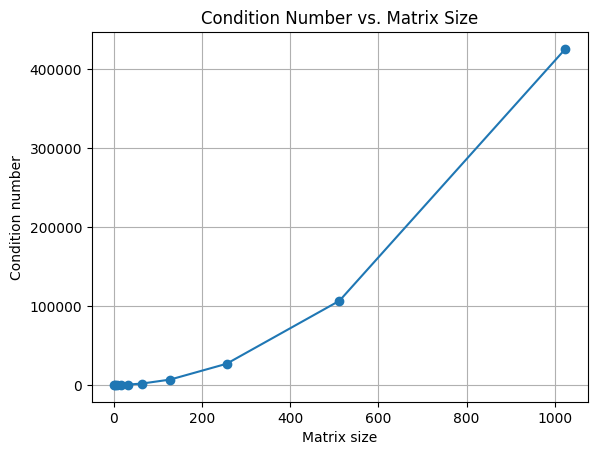

$lpha$ is approximately 1.9168186158185407 and C is approximately 0.6430252078977974


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def matrix_and_condition_num(k):
    N = 2 ** k
    main_diag = 2 * np.ones(N)
    off_diag = -1 * np.ones(N - 1) #The elements beside the diagonal are -1
    matrix = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1) # this is how the np combines the diagonal matrices

    condition_num = np.linalg.cond(matrix, p=2)  #we want the 2 norm condition number
    return matrix, condition_num

print(matrix_and_condition_num(7)) #example

# now let's plot
def plot_condition_numbers(k_min, k_max):
    #Compute and plot κ2(A_N) vs N for k in [k_min, k_max]
    k_values = range(k_min, k_max + 1)
    N_values = []
    condition_numbers = []

    for k in k_values:
        _, cond = matrix_and_condition_num(k)
        N = 2 ** k
        N_values.append(N)
        condition_numbers.append(cond)

    # Plot
    plt.figure()
    plt.plot(N_values, condition_numbers, marker='o')
    plt.xlabel("Matrix size")
    plt.ylabel("Condition number")
    plt.title("Condition Number vs. Matrix Size")
    plt.grid(True)
    plt.show()
    
    #############################################################
    """ FROM HERE ON EXERCISE (b) """
    #############################################################
    #Now we estimate alpha
    log_N = np.log(N_values)
    log_cond = np.log(condition_numbers)
    coeffs = np.polyfit(log_N, log_cond, deg=1) #log(cond) approx. alpha*log(N) + log(C)
    alpha_estimate = coeffs[0] #slope is alpha
    C_estimate = np.exp(coeffs[1])
    
    print(f"Alpha is approximately {alpha_estimate} and C is approximately {C_estimate}")
    

plot_condition_numbers(1, 10)

### (b) Explanation

My observation: alpha is approximately 2.

### (c)

First we can estimate $\lambda_{max}$ by predicting that $\sin(x)$ will be largest when $n = N$, since that's when $x \approx \pi/2$ and $\lambda_{max} \approx 4$. Next we can deduct, that $\lambda_{min} = \lambda_{1}$. Thats when x will be smallest and for small $x$, $\sin(x) \approx x$. From here we can estimate: $\lambda_{min} \approx 4 * (\frac{\pi}{(2(N + 1))})^2 \approx \frac{\pi^2}{(N + 1)^2} => \kappa \approx \frac{4}{\pi^2}(N + 1)^2 \approx \frac{4}{\pi^2}N^2$. We can see that this is the desired form of this formula, since now we can deduct that when N -> $\infty$, $\kappa -> \infty$ and also that $C \approx \frac{4}{\pi^2} \approx 0.41$, which is similar to the C that we got from (b) where $C \approx 0,64$. In this form of the formula we can also observe that $\alpha \approx 2$, which further confirms our suspitions in (b).